# Block Classification Matrix (3x3 Grid)
**Goal:** 
To isolate specific blocks of price action, strip away the stock ticker, and classify the block purely based on its mathematical behavior.

**The Architecture:**
* **Target:** 5% Return in 13 Days.
* **Regime Lookback:** 26 Days (SuperTrend Period).
* **Block Size:** 26 Days (Exactly matching the Regime Lookback for maximum reactivity).

**The Two Vectors:**
1. **Y-Axis (Reward/Hit Rate):** % of days in the block where the stock successfully returned >= 5% within the next 13 days.
2. **X-Axis (Risk/Volatility):** Annualized standard deviation of daily returns during the block.


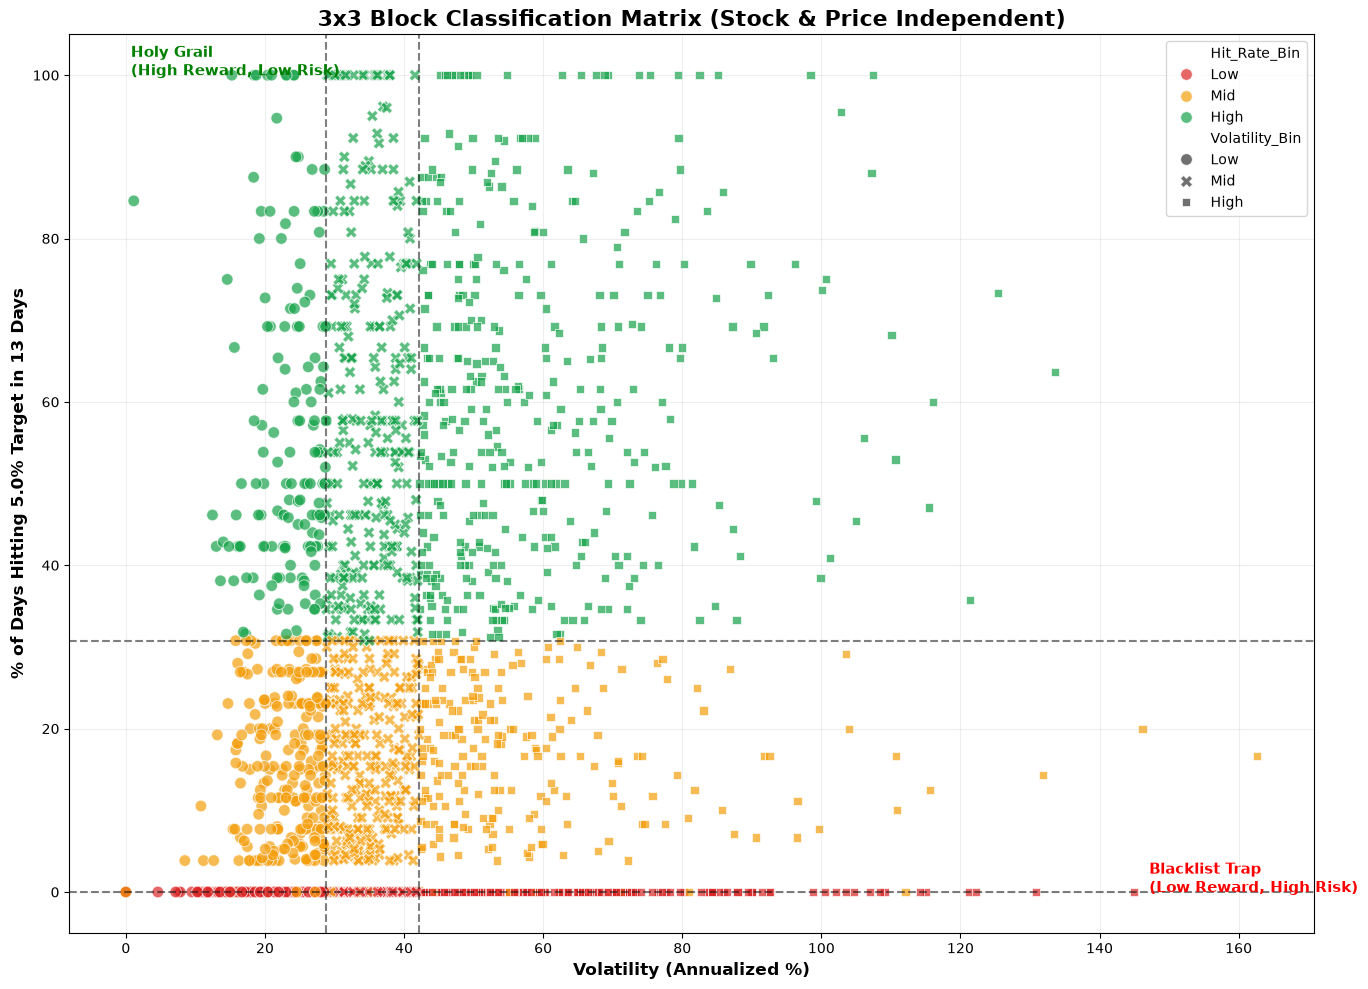

Volatility_Bin,Low,Mid,High,All
Hit_Rate_Bin,,,,
Low,394,239,204,837
Mid,291,313,233,837
High,152,285,400,837
All,837,837,837,2511


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob

# 1. CONFIGURATION
TARGET_RETURN = 5.0       # 5% target
TARGET_DAYS = 13          # 13 day limit
REGIME_LOOKBACK = 26      # Supertrend period
BLOCK_SIZE = REGIME_LOOKBACK      # 26 Days

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:50] # Use 50 stocks for a good scatter sample

os.makedirs('../output', exist_ok=True)

# 2. EXTRACT VECTORS FROM BLOCKS
block_data = []

def calc_supertrend(df, period=REGIME_LOOKBACK, multiplier=3.0):
    high, low, close = df['High'], df['Low'], df['Close']
    tr = pd.concat([high - low, (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.rolling(period).mean()
    hl2 = (high + low) / 2
    basic_ub, basic_lb = hl2 + (multiplier * atr), hl2 - (multiplier * atr)
    
    final_ub, final_lb, trend = np.zeros(len(df)), np.zeros(len(df)), np.ones(len(df))
    for i in range(period, len(df)):
        final_ub[i] = basic_ub.iloc[i] if basic_ub.iloc[i] < final_ub[i-1] or close.iloc[i-1] > final_ub[i-1] else final_ub[i-1]
        final_lb[i] = basic_lb.iloc[i] if basic_lb.iloc[i] > final_lb[i-1] or close.iloc[i-1] < final_lb[i-1] else final_lb[i-1]
        if close.iloc[i] > final_ub[i-1]: trend[i] = 1
        elif close.iloc[i] < final_lb[i-1]: trend[i] = -1
        else: trend[i] = trend[i-1]
    return trend

for file_path in all_files:
    try:
        df = pd.read_csv(file_path)
        if len(df) < BLOCK_SIZE: continue
        
        # Calculate Regime
        df['ST_Trend'] = calc_supertrend(df, period=REGIME_LOOKBACK, multiplier=2.5)
        
        # Calculate forward 13-day returns
        df['Forward_13d_Ret'] = (df['Close'].shift(-TARGET_DAYS) - df['Close']) / df['Close'] * 100
        df['Hit_Target'] = np.where(df['Forward_13d_Ret'] >= TARGET_RETURN, 1, 0)
        df['Daily_Ret'] = df['Close'].pct_change() * 100
        
        # Chop into non-overlapping 260-day blocks
        num_blocks = len(df) // BLOCK_SIZE
        
        for i in range(num_blocks):
            start_idx = i * BLOCK_SIZE
            end_idx = start_idx + BLOCK_SIZE
            block = df.iloc[start_idx:end_idx].dropna(subset=['Daily_Ret'])
            
            # Isolate ONLY the UP Regime days in this block!
            up_block = block[block['ST_Trend'] == 1]
            
            # Anomaly Filter: Throw away the entire block if any single day has a >20% gap
            if block['Daily_Ret'].abs().max() > 20: continue
            
            # Require at least 5 days of UP regime to run stats in a 26-day block
            if len(up_block) < 5: continue
            
            # Vector 1: Hit Rate (%) inside UP Regime
            hit_rate = up_block['Hit_Target'].mean() * 100
            
            # Vector 2: Volatility (Annualized) inside UP Regime
            volatility = up_block['Daily_Ret'].std() * np.sqrt(252)
            
            block_data.append({
                'Stock': os.path.basename(file_path).split('.')[0],
                'Block_Index': i,
                'Hit_Rate': hit_rate,
                'Volatility': volatility
            })
    except:
        pass

results = pd.DataFrame(block_data)
results = results.dropna()

# 3. BUILD THE 3x3 CLASSIFICATION GRID
# Use pandas qcut to automatically find the perfect 33rd and 66th percentiles for the grid
# We add microscopic noise to prevent ValueError if >33% of blocks have exactly 0% Hit Rate
results['Hit_Rate_Bin'] = pd.qcut(results['Hit_Rate'] + np.random.uniform(0, 0.000001, len(results)), q=3, labels=['Low', 'Mid', 'High'])
results['Volatility_Bin'] = pd.qcut(results['Volatility'] + np.random.uniform(0, 0.000001, len(results)), q=3, labels=['Low', 'Mid', 'High'])

# 4. PLOT THE MATRIX
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=results, 
    x='Volatility', 
    y='Hit_Rate', 
    hue='Hit_Rate_Bin',
    style='Volatility_Bin',
    palette=['#dc2626', '#f59e0b', '#16a34a'], # Red, Yellow, Green
    s=70, 
    alpha=0.7
)

# Draw the 3x3 Grid Lines based on the exact threshold cuts
vol_cuts = [results[results['Volatility_Bin'] == 'Low']['Volatility'].max(), 
            results[results['Volatility_Bin'] == 'Mid']['Volatility'].max()]
hit_cuts = [results[results['Hit_Rate_Bin'] == 'Low']['Hit_Rate'].max(), 
            results[results['Hit_Rate_Bin'] == 'Mid']['Hit_Rate'].max()]

for v in vol_cuts:
    plt.axvline(v, color='black', linestyle='--', alpha=0.5)
for h in hit_cuts:
    plt.axhline(h, color='black', linestyle='--', alpha=0.5)

plt.title('3x3 Block Classification Matrix (Stock & Price Independent)', fontsize=16, weight='bold')
plt.xlabel('Volatility (Annualized %)', fontsize=12, weight='bold')
plt.ylabel(f'% of Days Hitting {TARGET_RETURN}% Target in {TARGET_DAYS} Days', fontsize=12, weight='bold')
plt.grid(True, alpha=0.2)

# Annotate Quadrants (Examples)
plt.text(results['Volatility'].min(), results['Hit_Rate'].max(), ' Holy Grail\n (High Reward, Low Risk)', color='green', weight='bold', fontsize=11)
plt.text(results['Volatility'].max() * 0.9, results['Hit_Rate'].min() * 1.1, ' Blacklist Trap\n (Low Reward, High Risk)', color='red', weight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../output/3x3_matrix_scatter.jpg', format='jpeg')
plt.show()

# Show the Grid Distribution Stats
display(pd.crosstab(results['Hit_Rate_Bin'], results['Volatility_Bin'], margins=True))


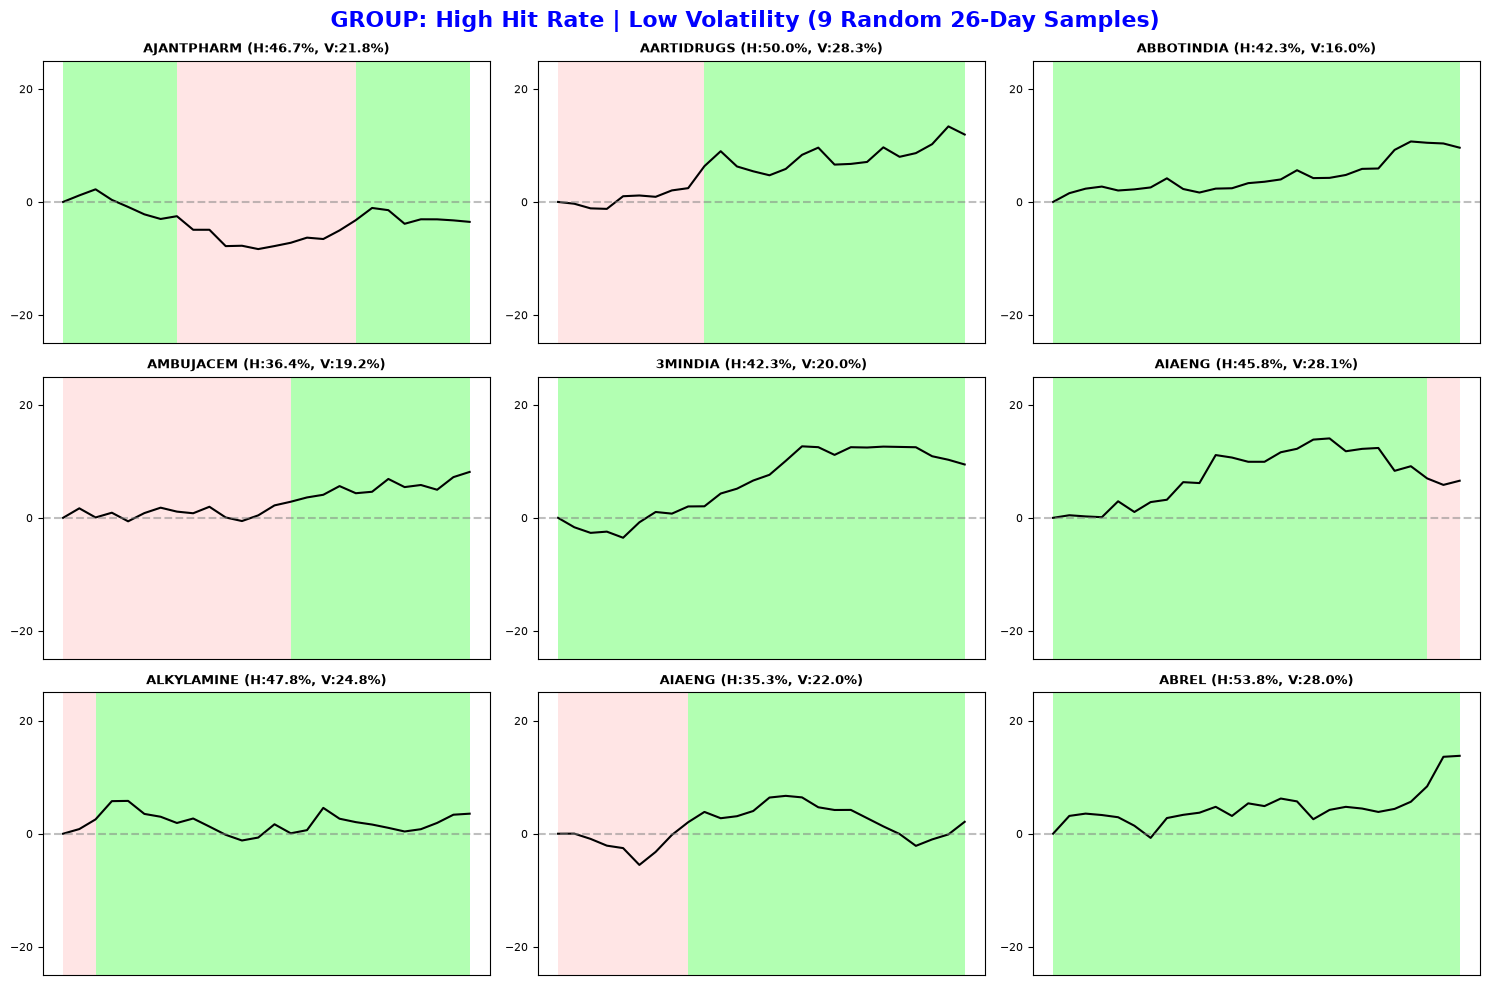

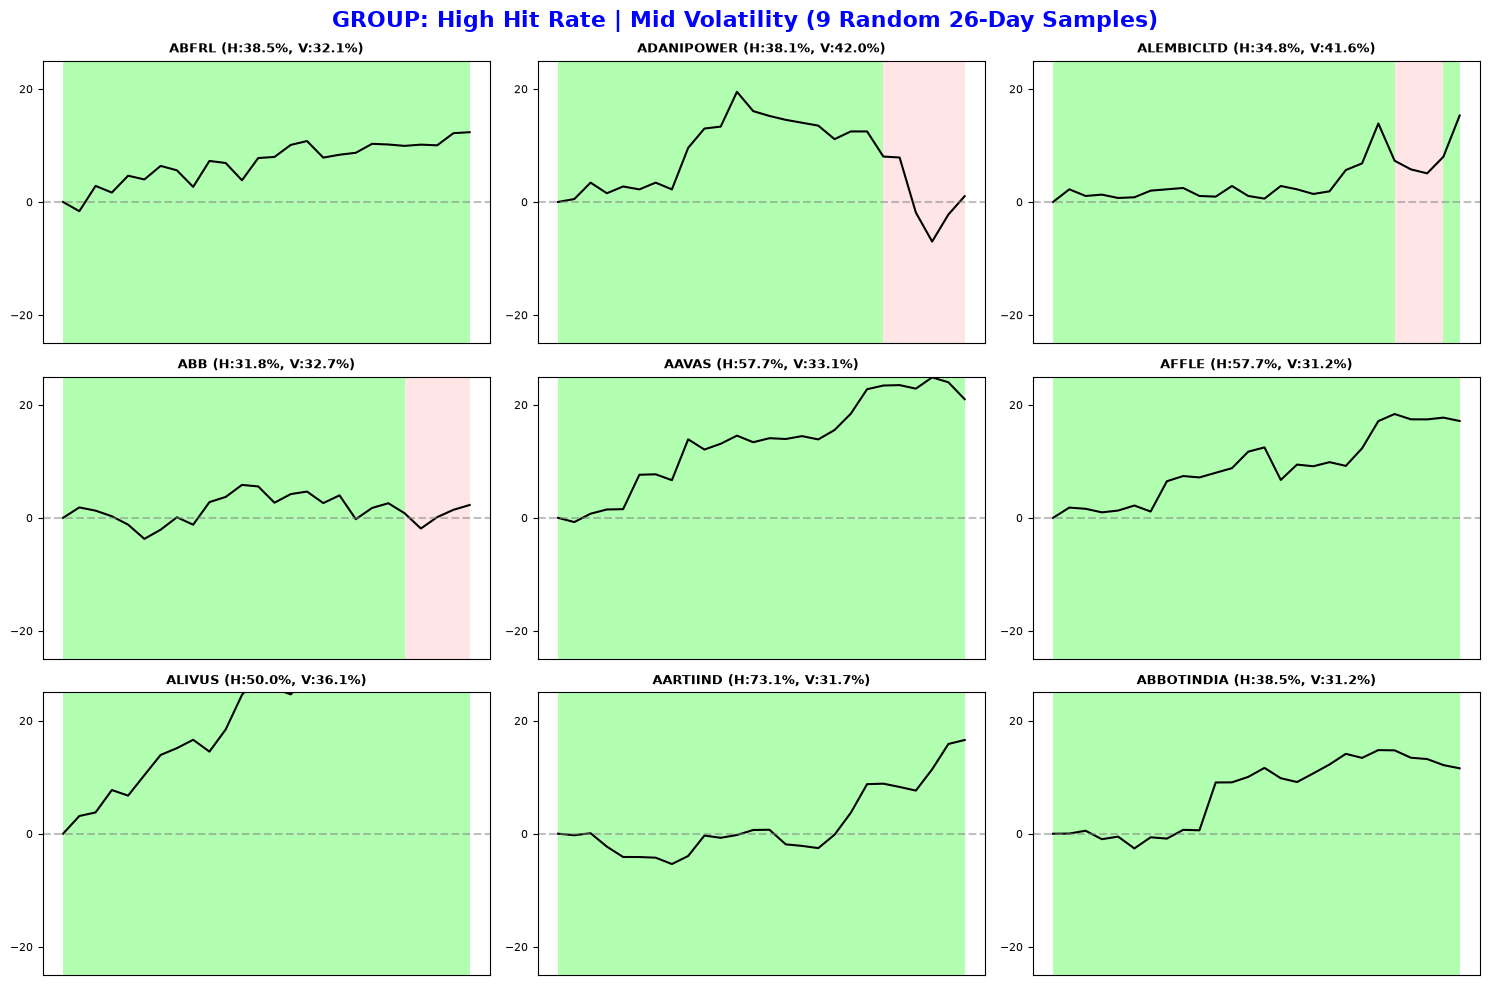

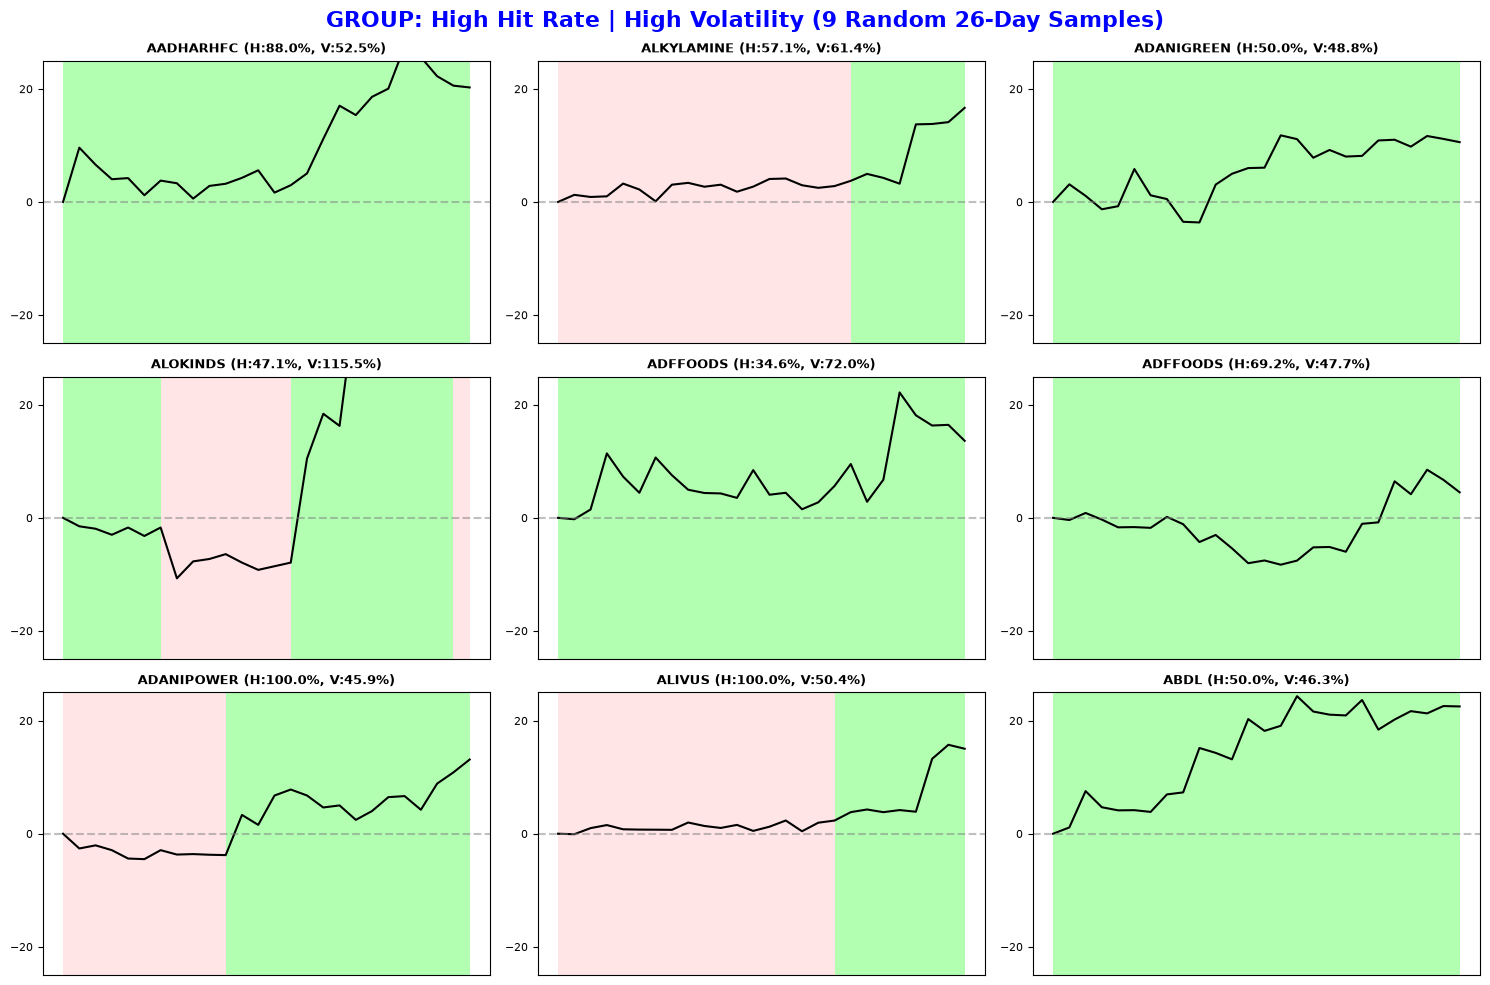

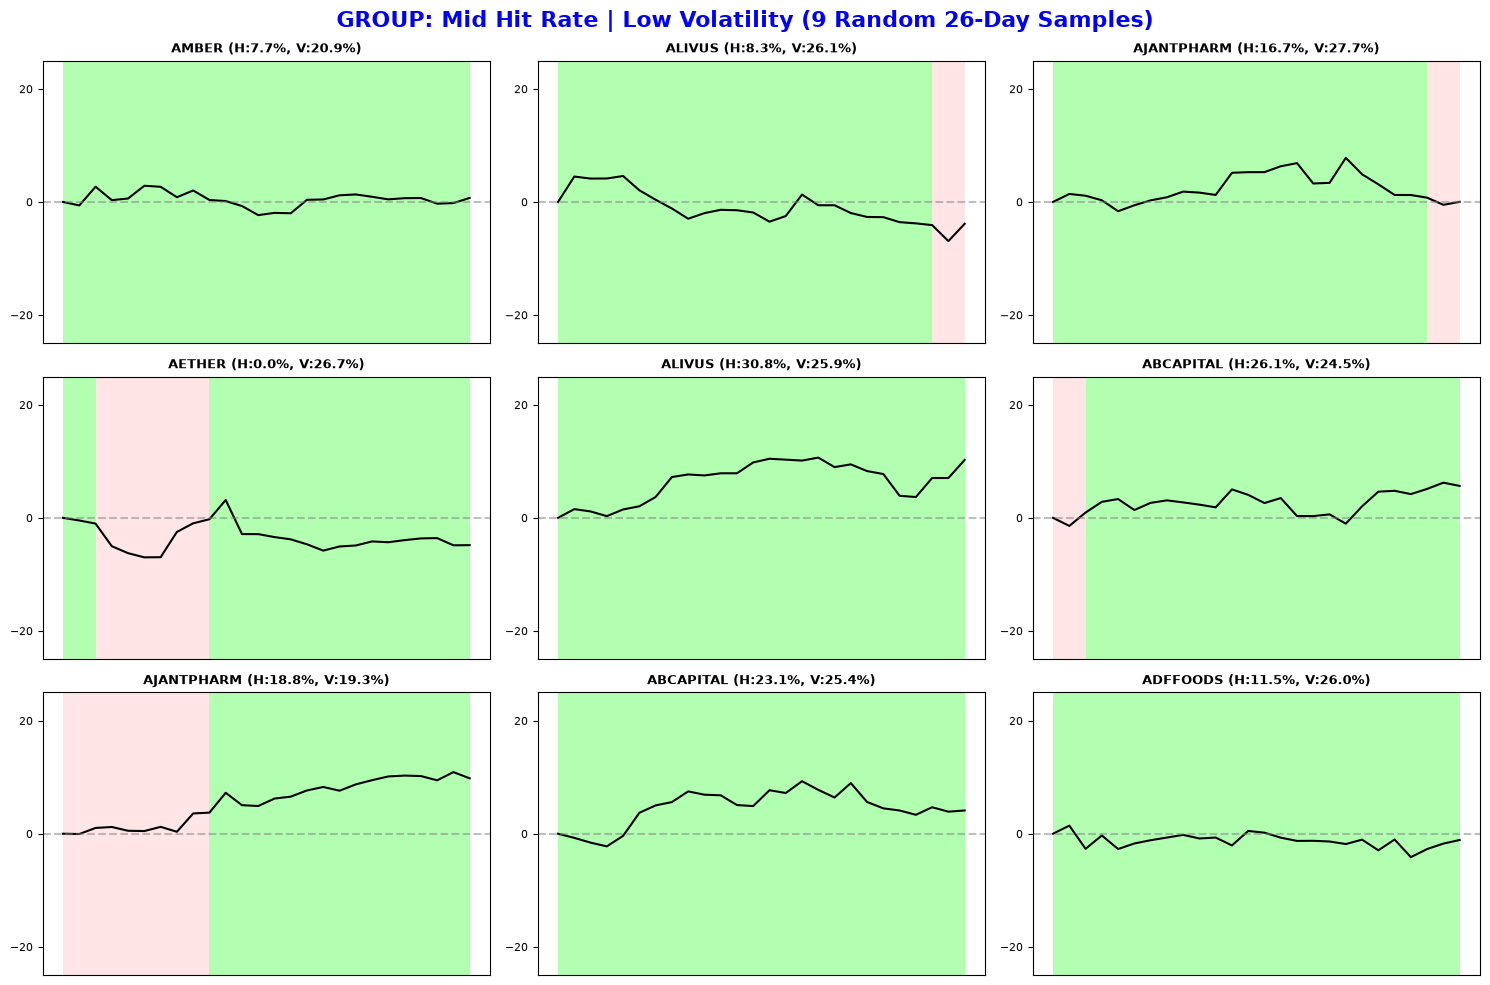

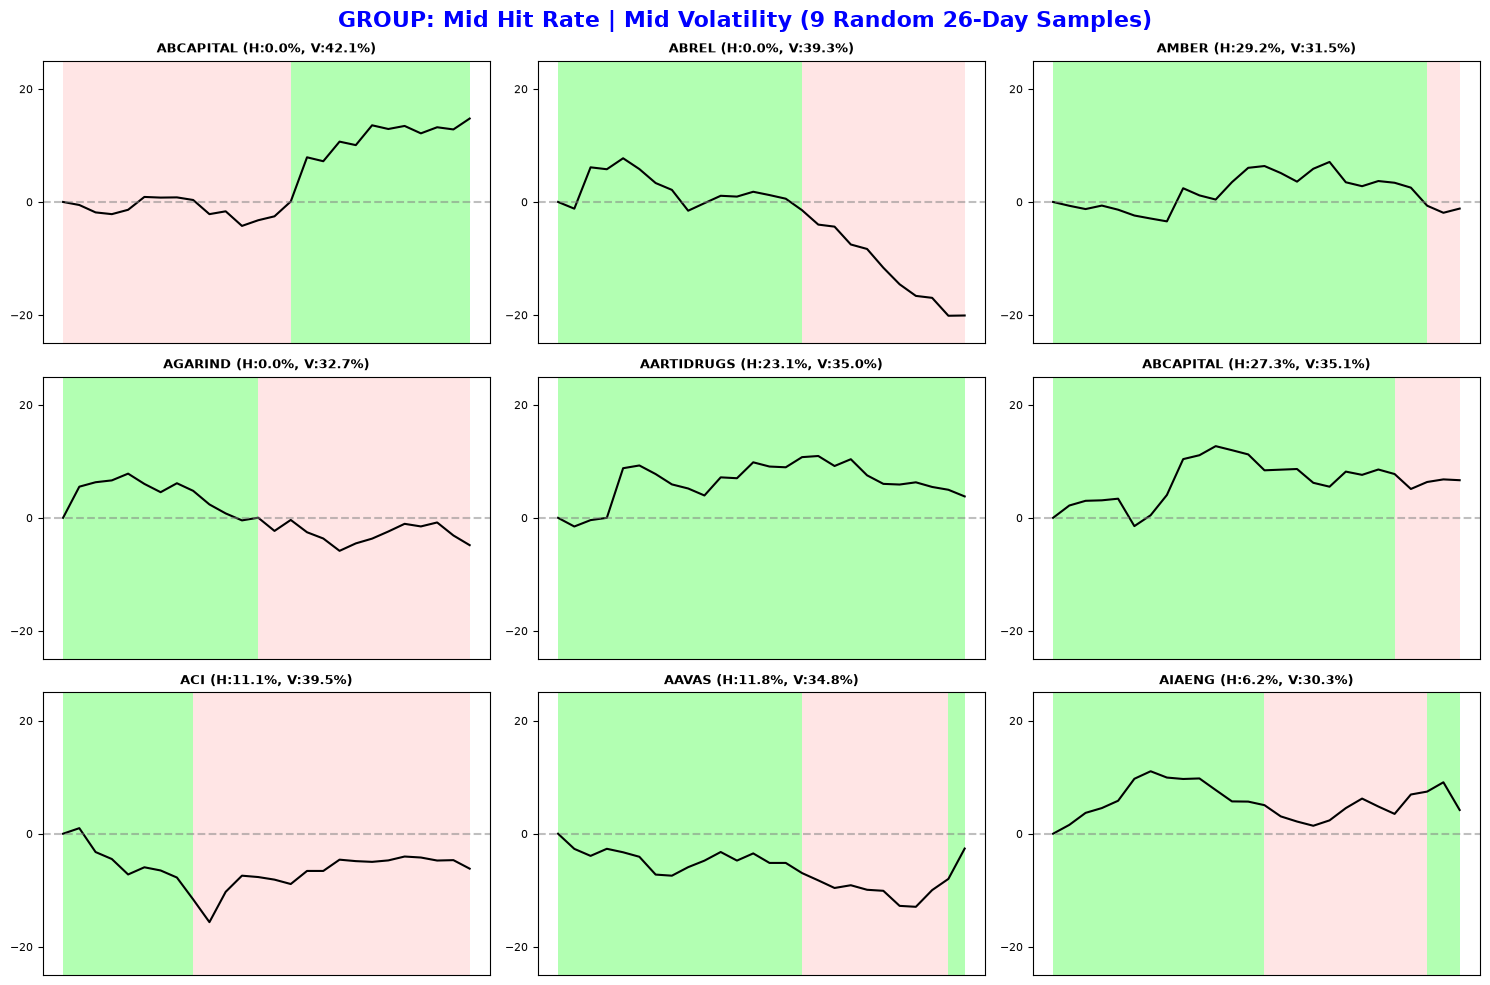

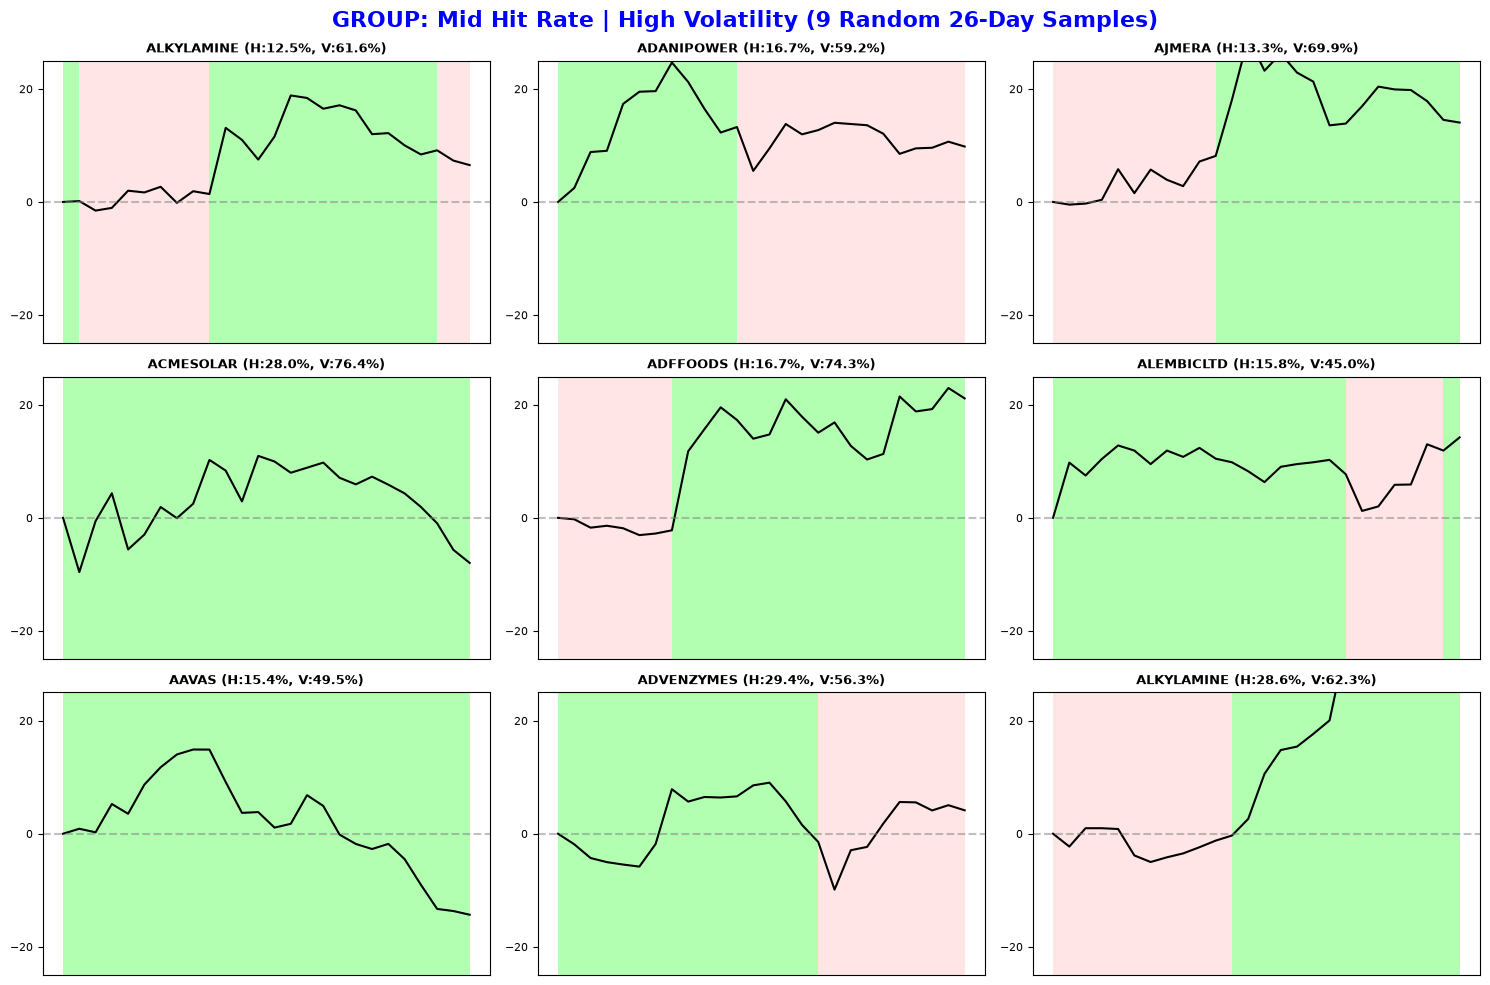

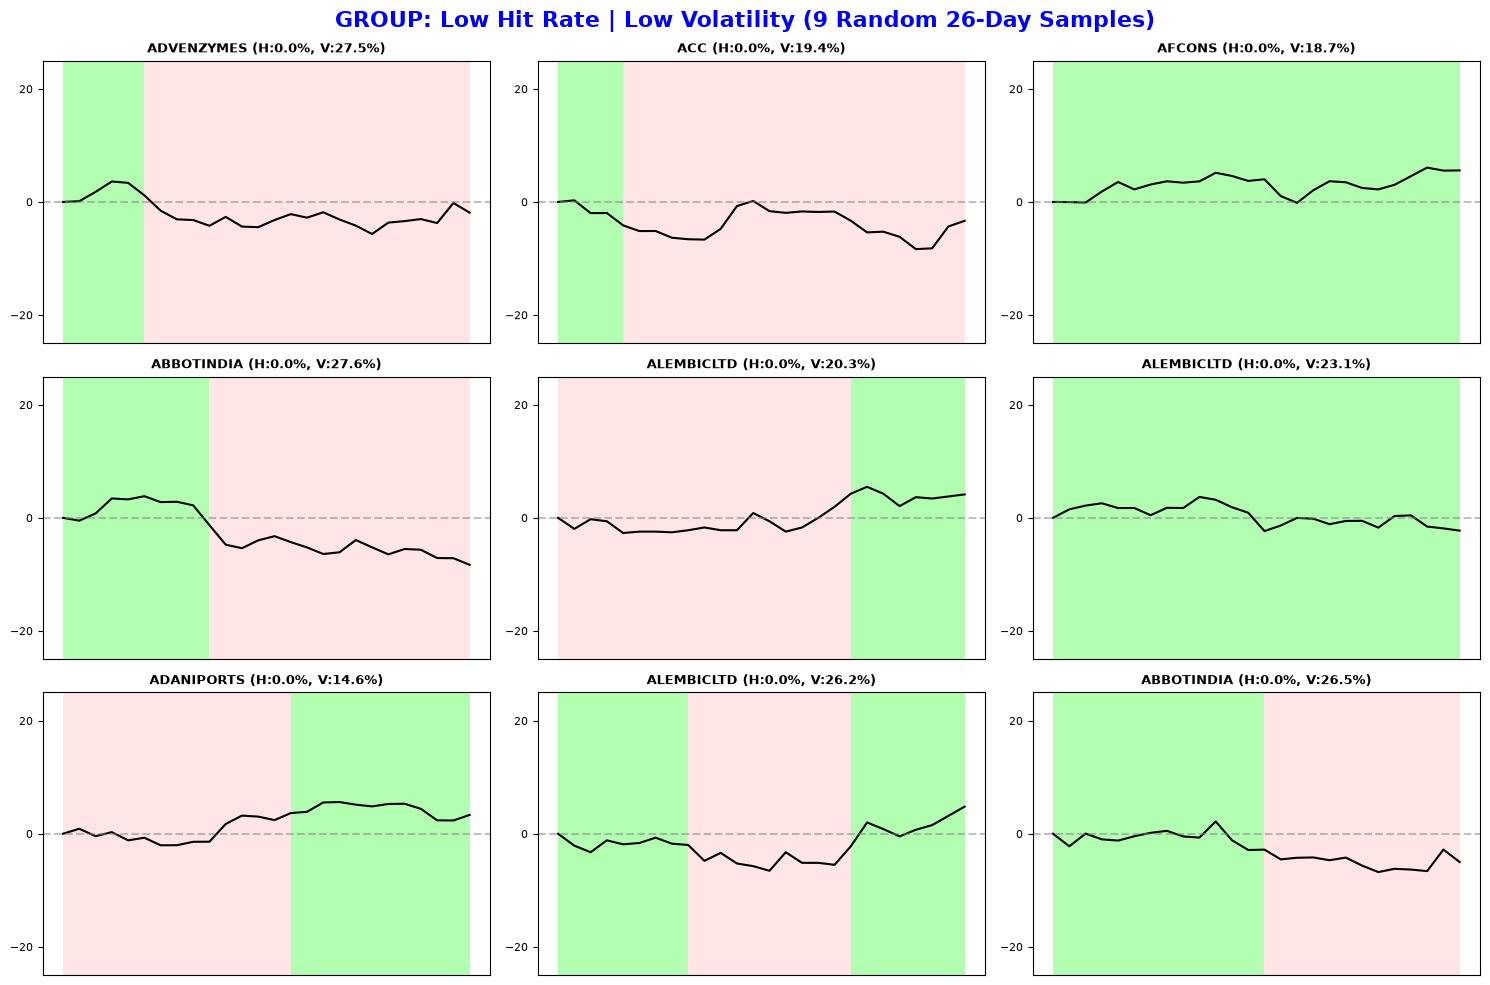

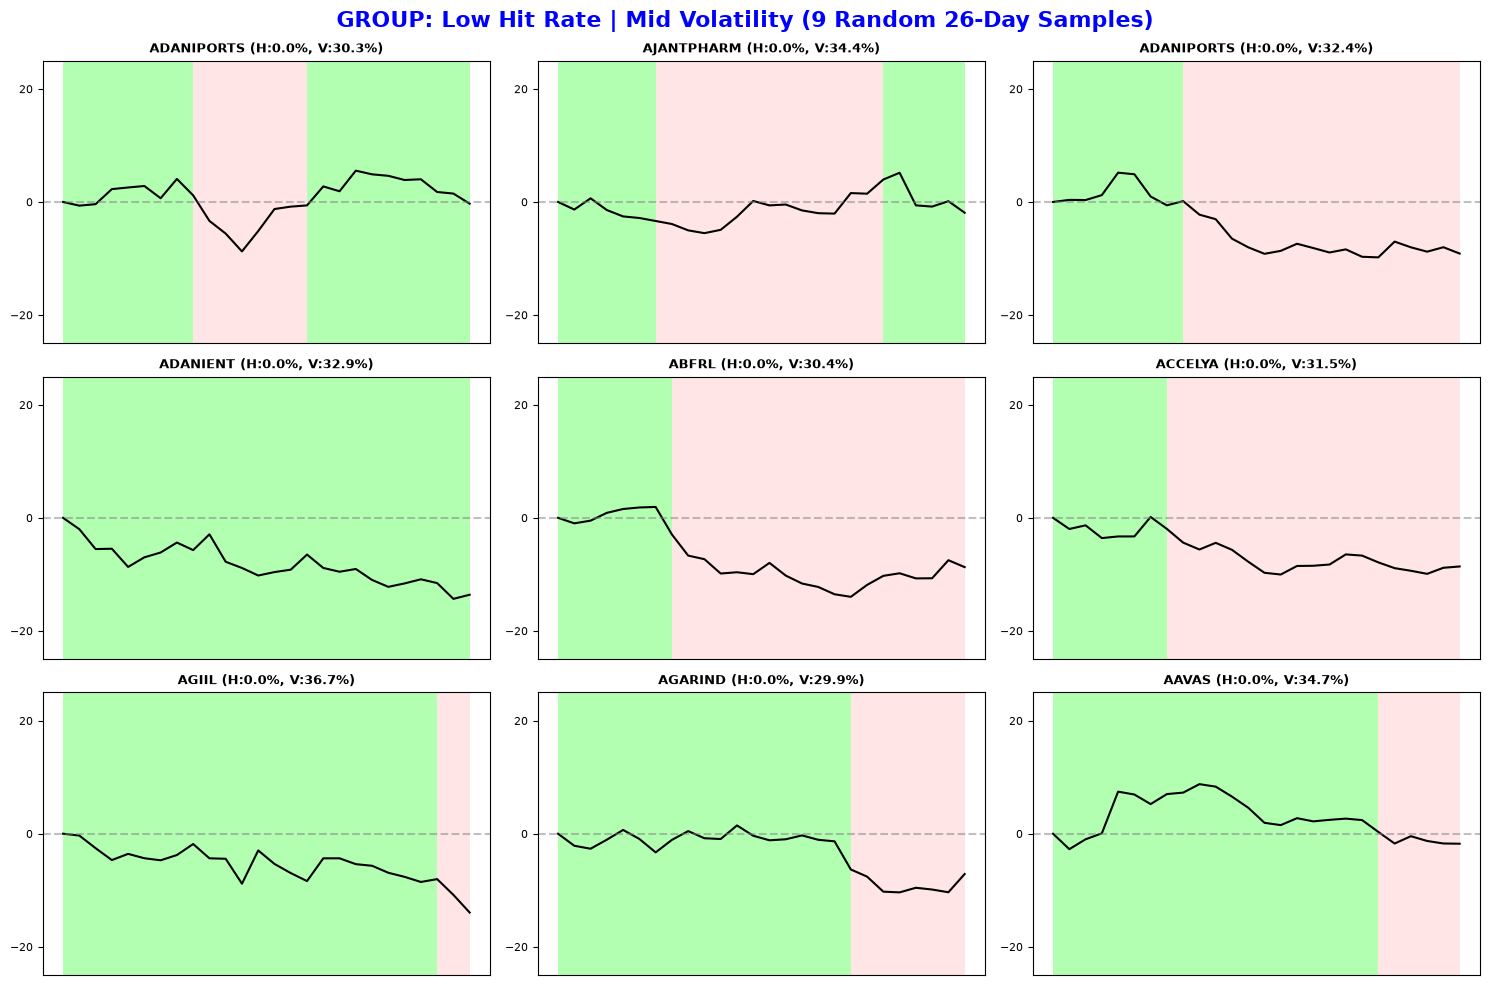

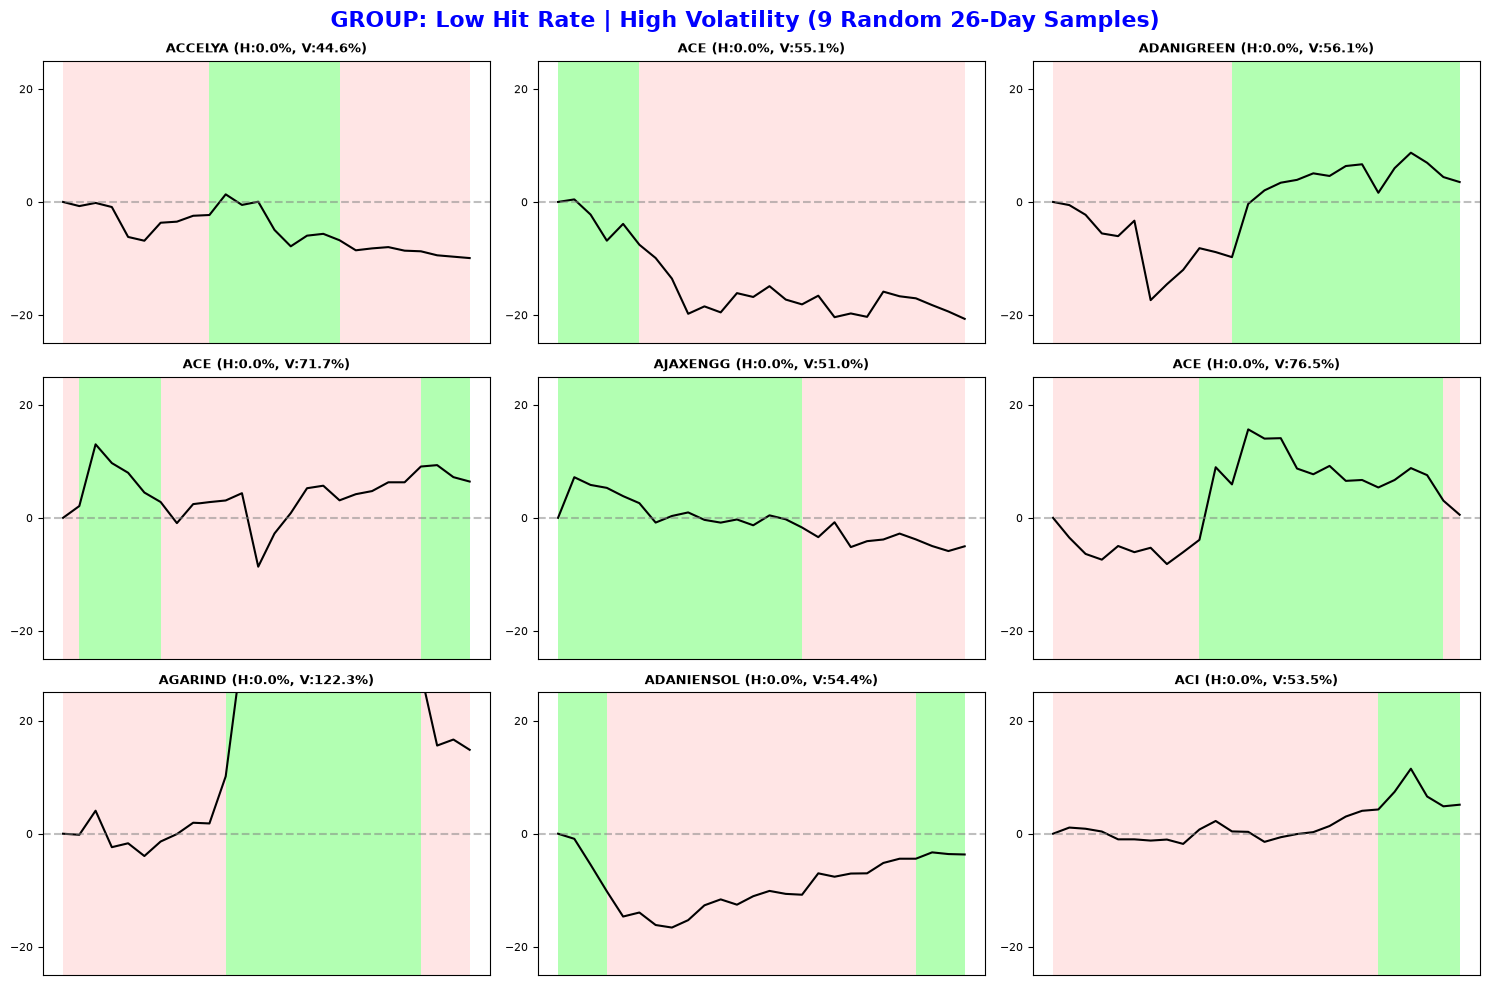

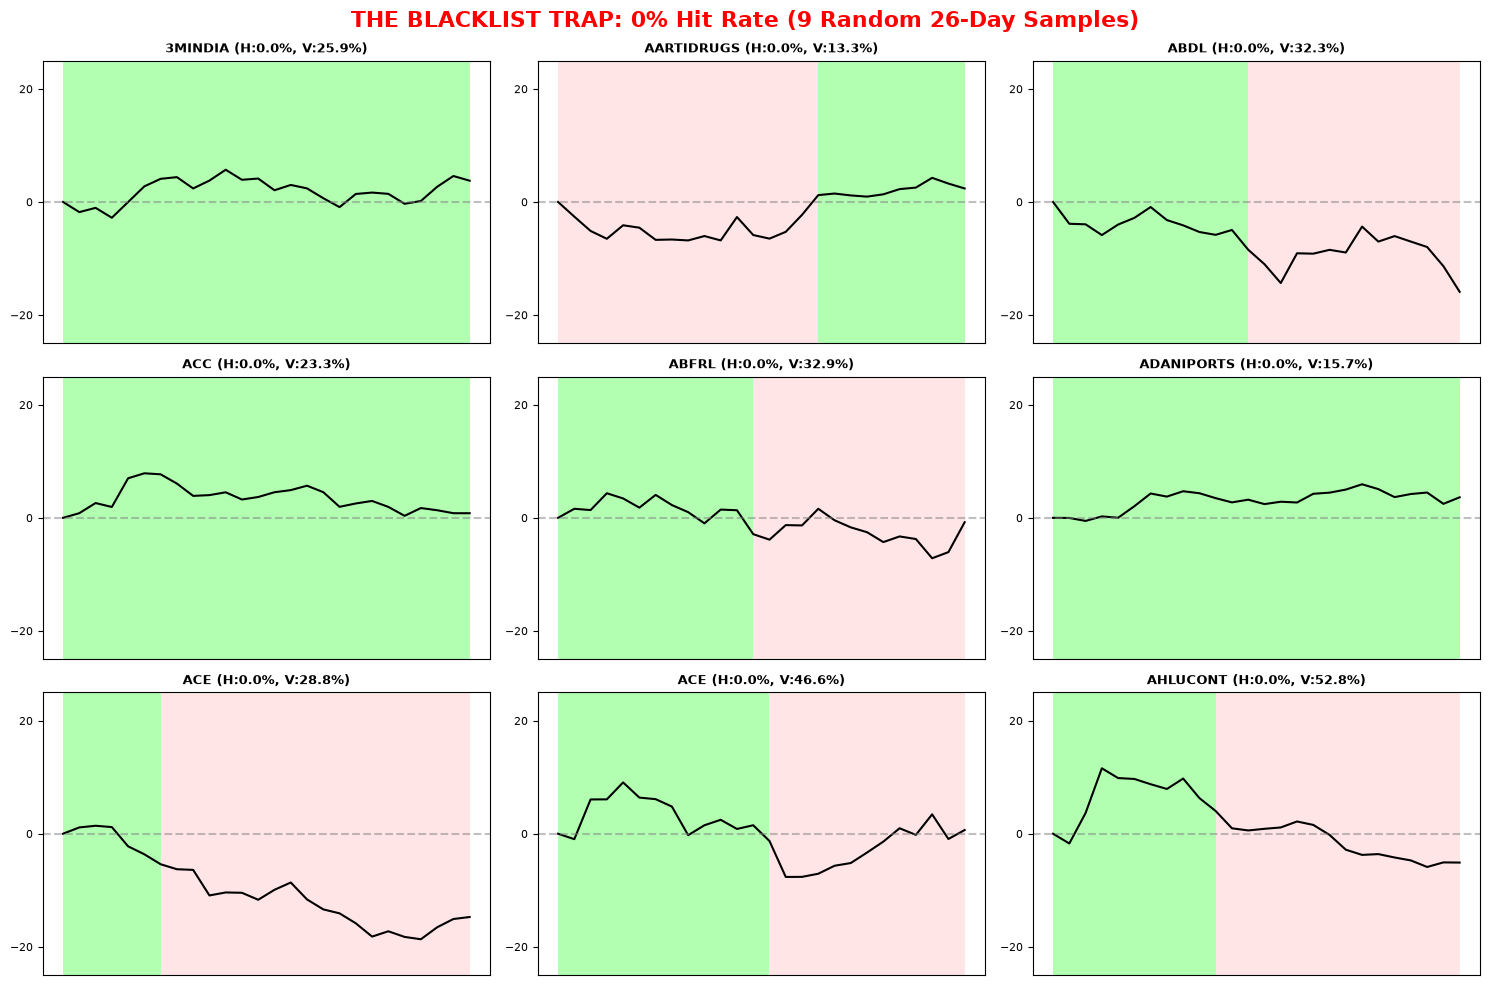

In [2]:

# 5. VISUALIZE 9 REPRESENTATIVE BLOCKS FROM EACH GROUP (81+ PLOTS TOTAL)
import matplotlib.pyplot as plt

def plot_sample_block(row, ax):
    stock = row['Stock']
    b_idx = int(row['Block_Index'])
    hit = row['Hit_Rate']
    vol = row['Volatility']
    
    # Reload data
    file_path = os.path.join(DATA_DIR, f"{stock}.csv")
    try:
        df = pd.read_csv(file_path)
        df['ST_Trend'] = calc_supertrend(df, period=REGIME_LOOKBACK, multiplier=2.5)
        
        start_idx = b_idx * BLOCK_SIZE
        end_idx = start_idx + BLOCK_SIZE
        block = df.iloc[start_idx:end_idx].copy()
        
        # Normalize to % change from the start of the block
        start_price = block['Close'].iloc[0]
        block_pct = ((block['Close'] / start_price) - 1) * 100
        
        ax.plot(range(len(block)), block_pct, color='black', lw=1.5)
        
        # Add a faint baseline at 0%
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        
        # Highlight UP regime in green
        for i in range(1, len(block)):
            if block['ST_Trend'].iloc[i] == 1:
                ax.axvspan(i-1, i, color='lime', alpha=0.3, lw=0)
            else:
                ax.axvspan(i-1, i, color='red', alpha=0.1, lw=0)
                
        ax.set_title(f"{stock} (H:{hit:.1f}%, V:{vol:.1f}%)", fontsize=9, weight='bold')
        
        # LOCK THE Y-AXIS SCALE for pure visual comparison
        ax.set_ylim(-25, 25)
    except:
        pass
    ax.set_xticks([])
    # Optional: Keep y-ticks on the very left plots to show the scale, but for now we hide them or show them
    # Let's keep it clean but locked
    ax.set_yticks([-20, 0, 20])
    ax.tick_params(axis='y', labelsize=8)

bins = ['Low', 'Mid', 'High']

# Iterate through all 9 combinations and plot a 3x3 grid for EACH group
for h_bin in reversed(bins): # High Hit rate first
    for v_bin in bins:
        subset = results[(results['Hit_Rate_Bin'] == h_bin) & (results['Volatility_Bin'] == v_bin)]
        samples = subset.sample(min(9, len(subset)))
        
        if len(samples) == 0: continue
            
        fig, axes = plt.subplots(3, 3, figsize=(15, 10))
        fig.suptitle(f"GROUP: {h_bin} Hit Rate | {v_bin} Volatility (9 Random 26-Day Samples)", fontsize=16, weight='bold', color='blue')
        axes = axes.flatten()
        
        for i, (_, row) in enumerate(samples.iterrows()):
            plot_sample_block(row, axes[i])
            
        plt.tight_layout()
        plt.show()

# ZERO LINE SAMPLES
zero_subset = results[results['Hit_Rate'] == 0]
zero_samples = zero_subset.sample(min(9, len(zero_subset)))

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(f"THE BLACKLIST TRAP: 0% Hit Rate (9 Random 26-Day Samples)", fontsize=16, weight='bold', color='red')
axes = axes.flatten()

for i, (_, row) in enumerate(zero_samples.iterrows()):
    plot_sample_block(row, axes[i])
    
plt.tight_layout()
plt.show()
